In [82]:
import numpy as np
import pandas as pd
import yaml
import os
from matplotlib import pyplot as plt
from hsa_hopper.kinematics import KinematicParameters
from hsa_hopper.controller import HopController
from hsa_hopper.hsa_model import HSAModel
kin_params = KinematicParameters(.07,.15,.3,-.005)

# load data
# root = r'C:\Users\Joseph Sullivan\Documents\hsa_hopper_control\data\aim2\hopping_data'
root = r'/home/joseph/workspaces/hsa_hopper/hsa_hopper_control/data/4_28/linear_model'
# root = r'/home/joseph/workspaces/hsa_hopper/hsa_hopper_control/data/4_28/nonlinear_model'
dataframes = {}
hardware_configs = {}
dynamics_params = {}
controller_params = {}
for category in os.listdir(root):
    if 'no_hsa' in category:
        continue
    if os.path.isfile(category):
        continue
    dataframes[category] = {}
    hardware_configs[category] = {}
    dynamics_params[category] = {}
    controller_params[category] = {}
    category_folder = os.path.join(root,category)
    total_mass = int(category.split('_')[-1][:-1])/1000
    for trial in os.listdir(category_folder):
        trial_folder = os.path.join(category_folder, trial)
        # load config files
        with open(os.path.join(trial_folder,'hardware_config.yaml')) as f:
            hardware_configs[category][trial] = yaml.load(f,yaml.Loader)
        with open(os.path.join(trial_folder,'experiment_config.yaml')) as f:
            experiment_config = yaml.load(f,yaml.Loader)
            dynamics_params[category][trial] = experiment_config['dynamics_params']
            controller_params[category][trial] = experiment_config['controller']
        # load (smoothed) data files
        trial_df = pd.read_csv(os.path.join(trial_folder,'data.csv'))
        m_cart = experiment_config['dynamics_params']['m_cart']
        m_foot = experiment_config['dynamics_params']['m_foot']
        trial_df['total_mass'] = m_cart+m_foot 
        trial_df['psi'] = experiment_config['dynamics_params']['psi']
        col_map = {col: i for i,col in enumerate(trial_df.columns)}
        # chop-off the end of stance and the end of flight phases
        stance_drop_count = 0
        flight_drop_count = 15
        min_stance_duration = 80
        keep_rows = np.ones(len(trial_df), dtype=bool)
        row_offset = 0
        for hop_idx in trial_df['hop_idx'].unique():
            try:
                hop_start = next(i for i in range(row_offset,len(trial_df)) if trial_df['hop_idx'][i] == hop_idx)
                hop_end = next(i for i in range(hop_start,len(trial_df)) if trial_df['hop_idx'][i] != hop_idx)
                row_offset = hop_end
            except:
                print(f"final hop at index {hop_idx} of trial {trial} in category {category} is incomplete. Dropping!")
                keep_rows[hop_start:] = False
                break
            try:
                flight_start = next(i for i in range(hop_start,len(trial_df)) if trial_df['mode'][i] == HopController._FLIGHT)
                if flight_start-hop_start < min_stance_duration:
                    # the control mode is likely chattering, so drop the hop
                    keep_rows[hop_start:hop_end] = False
                    print(f'dropping {range(hop_start,hop_end)} from hop {hop_idx} of trial {trial} in category {category}')
                else:
                    # trim the stance mode
                    keep_rows[hop_start:hop_start+stance_drop_count] = False
                    # keep_rows[flight_start-stance_drop_count:flight_start] = False
                    # trim the flight mode
                    keep_rows[hop_end-flight_drop_count:hop_end] = False
            except: # no flight period, drop the hop
                keep_rows[hop_start:hop_end] = False
                continue
        trial_df = trial_df.iloc[keep_rows,:]
        dataframes[category][trial] = trial_df

actuator_model_path = r'/home/joseph/workspaces/hsa_hopper/hsa_hopper_control/notebooks/actuator_model.yaml'
with open(actuator_model_path, 'r') as f:
    actuator_model = yaml.load(f, yaml.Loader)

# char_model_path = r'/home/joseph/workspaces/hsa_hopper/hsa_hopper_control/notebooks/hsa_model.yaml'

final hop at index 50 of trial 0deg in category hsa_1700g is incomplete. Dropping!
final hop at index 51 of trial 45deg in category hsa_1700g is incomplete. Dropping!
final hop at index 51 of trial 22deg in category hsa_1700g is incomplete. Dropping!
final hop at index 54 of trial 67deg in category hsa_1700g is incomplete. Dropping!


In [83]:
# concatenate data into one master dataframe
from hsa_hopper.controller import HopController
with_hsa_dfs = []
without_hsa_dfs = []
for category, trials in dataframes.items():
    for trial, df in trials.items():
        if dynamics_params[category][trial]['hsa_model'] is None:
            without_hsa_dfs.append(df)
        else:
            with_hsa_dfs.append(df)

WITH_HSA_DF = pd.concat(with_hsa_dfs)
# WITHOUT_HSA_DF = pd.concat(without_hsa_dfs)

In [84]:
MASTER_DF = WITH_HSA_DF
MASTER_DF['psi'].unique()
MASTER_DF['total_mass'].unique()
MASTER_DF['mode'].unique()

array([2, 1])

In [85]:
from numpy.random import default_rng
from copy import copy

rng = default_rng(seed=42)
N_ROWS = len(MASTER_DF)
ROWS = list(range(N_ROWS))
rng.shuffle(ROWS)
N_TRAIN = 100*N_ROWS//100
N_TEST = N_ROWS-N_TRAIN
TRAIN_INDICES = ROWS[:N_TRAIN]
TEST_INDICES = ROWS[N_TRAIN:]

In [86]:
from hsa_hopper.hsa_model import HSAModel
from hsa_hopper.controller import HopController
def make_lstsq_data(model: HSAModel, actuator_model: dict, frame: pd.DataFrame):
    N = model.num_params()
    M = len(frame)
    A = np.zeros((M,N))
    b = np.zeros(M)
    l = frame['l_m'].to_numpy()
    xdot = frame['xdot'].to_numpy()
    ldot = frame['ldot'].to_numpy()
    ydot = frame['ydot'].to_numpy()
    xddot = frame['xddot'].to_numpy()
    lddot = frame['lddot'].to_numpy()
    yddot = frame['yddot'].to_numpy()
    tau = frame['torque'].to_numpy()
    dldx = frame['dldx'].to_numpy()
    dydx = frame['dydx'].to_numpy()
    psi = frame['psi'].to_numpy()
    mode = frame['mode'].to_numpy()
    total_mass = frame['total_mass'].to_numpy()

    stance_mdot = (dydx*yddot)
    flight_mdot = (dldx*lddot)
    stance_grav = (dydx*9.81)
    flight_grav = (dldx*9.81)
    m_cart = total_mass - actuator_model['m_foot']
    m_foot = actuator_model['m_foot']
    b = tau
    b -= m_cart*(mode == HopController._STANCE)*(stance_grav+stance_mdot)
    b -= m_foot*(mode == HopController._FLIGHT)*(flight_grav+flight_mdot)
    b -= actuator_model['J']*xddot
    b -= actuator_model['bx']*xdot

    A[:,0] = dldx*l # HSA linear spring constant (K) column
    A[:,1] = dldx   # HSA linear spring offset (F0) column
    A[:,2] = dldx*ldot   # HSA linear damping coefficient (bl) column

    # Nonlinear spring and damper parameters
    if model.y is not None:
        ks, kd, dks, dkd = model.covectors(l, ldot, psi, grad=True)
        offset = 3
        if ks is not None:
            for i in range(ks.shape[0]):
                A[:,offset+i] = dks[i,:]*dldx
            offset += ks.shape[0]
        if kd is not None:
            for i in range(kd.shape[0]):
                A[:,offset+i] = dkd[i,:]*dldx
    return A,b

In [87]:
def make_weight_regularizer(hsa_model: HSAModel, frame: pd.DataFrame):
    l = frame['l_m'].to_numpy()
    ldot = frame['ldot'].to_numpy()
    psi = frame['psi'].to_numpy()
    dldx = frame['dldx'].to_numpy()
    num_params = hsa_model.num_params()
    A = np.zeros((len(frame), num_params))
    if hsa_model.y is not None:
        kc, kd, dkc, dkd = hsa_model.covectors(l,ldot,psi,grad=True)
        num_params = hsa_model.num_params()
        offset = 3
        if hsa_model.w_c is not None:
            for i in range(hsa_model.w_c.size):
                A[:,offset+i] = (dkc[i,:]*dldx)
            offset += hsa_model.w_c.size
        if hsa_model.w_d is not None:
            for i in range(hsa_model.w_d.size):
                A[:,offset+i] = (dkd[i,:]*dldx)
    return A

In [88]:
"""
Experimental - fitting two potential functions and blending them together with a logistic function
"""

from scipy.optimize import minimize
from scipy.optimize import LinearConstraint
from hsa_hopper.hsa_model import HSAModel 

# function to do the model optimization
def governing_equation_lstsq(hsa_model, actuator_model, reg_penalty, optimize=True):
    N = hsa_model.num_params()
    A,b = make_lstsq_data(hsa_model,actuator_model,MASTER_DF.iloc[TRAIN_INDICES,:])
    B = make_weight_regularizer(hsa_model, MASTER_DF.iloc[TRAIN_INDICES,:])
    # rescaling A matrix for better conditioning of constraint evaluation
    SCALE = np.ones(A.shape[1])
    SCALE[0] = 1 # linear spring constant rescaling
    SCALE[1] = 1 # linear force rescaling
    SCALE[2] = 1 # linear damping rescaling

    A_scaled = A*SCALE
    B_scaled = B*SCALE
    ATA = A_scaled.T@A_scaled
    BTB = B_scaled.T@B_scaled
    ATb = A_scaled.T@b
    bTb = np.dot(b,b)
    f = lambda x: x.T@(ATA+reg_penalty*BTB)@x+bTb-2*x.T@ATb
    jac = lambda x: 2*(ATA+reg_penalty*BTB)@x-2*ATb

    x0 = np.zeros(N)
    x0[0] = hsa_model.K
    x0[1] = hsa_model.F0
    x0[2] = hsa_model.b
    offset = 3
    if hsa_model.w_c is not None:
        x0[offset:offset+hsa_model.w_c.size] = hsa_model.w_c
        offset += hsa_model.w_c.size
    if hsa_model.w_d is not None:
        x0[offset:] = hsa_model.w_d

    if not optimize:
        errors = (A_scaled@x0-b)
        sos_res = np.sum(errors**2)
        r_sqr = 1-sos_res/np.sum((b-np.average(b))**2)
        r_sqr_adj = 1-(1-r_sqr)*(b.size-1)/(b.size-1-N-1)
        mse = sos_res/b.size
        bic = b.size*np.log(mse)+N*np.log(b.size)
        errors = A@(SCALE*x0)-b
        result = {
            'r_sqr' : r_sqr,
            'r_sqr_adj' : r_sqr_adj,
            'bic' : bic,
            'errors' : errors
        }
        return result
    else:
        # rescaling matrix for parameters, useful for conditioning
        # the constraint evaluations

        # next constraints - enforce positive weights
        # and positive definiteness of stiffness/damping at basis centers
        C = np.eye(N)
        lb = np.array([500,-1000,0])
        ub = np.array([1000,1000,100])
        if hsa_model.w_c is not None:
            lb = np.hstack((lb, -1e3*np.ones(hsa_model.w_c.size)))
            ub = np.hstack((ub, 0*np.ones(hsa_model.w_c.size)))
        if hsa_model.w_d is not None:
            lb = np.hstack((lb, 0*np.ones(hsa_model.w_d.size)))
            ub = np.hstack((ub, 1e3*np.ones(hsa_model.w_d.size)))

        constraints = [LinearConstraint(C,lb=lb,ub=ub)]

        x0 = np.zeros(N)
        result = minimize(f, x0, 
                        jac=jac, 
                        constraints=constraints, 
                        method='SLSQP',
                        options={'maxiter' : 12000, 'ftol': 1e-12}
        )
        result.A = A
        result.b = b
        result.sample_size = b.shape[0]
        result.num_params = hsa_model.num_params()
        hsa_model.K = result.x[0]*SCALE[0]
        hsa_model.F0 = result.x[1]*SCALE[1]
        hsa_model.b = result.x[2]*SCALE[2]
        offset = 3
        if hsa_model.w_c is not None:
            hsa_model.w_c = result.x[offset:offset+hsa_model.w_c.size]
            offset += hsa_model.w_c.size
        if hsa_model.w_d is not None:
            hsa_model.w_d = result.x[offset:offset+hsa_model.w_d.size]
        result.model = hsa_model
        result.errors = (A_scaled@result.x-b)
        result.sos_errors = np.sum(result.errors**2)
        result.r_sqr = 1-result.sos_errors/np.sum((b-np.average(b))**2)
        result.r_sqr_adj = 1-(1-result.r_sqr)*(result.sample_size-1)/(result.sample_size-result.num_params-1)
        result.mse = result.sos_errors/result.sample_size
        result.rmse = np.sqrt(result.mse)
        result.bic = result.sample_size*np.log(result.mse)+result.num_params*np.log(result.sample_size)
        result.errors = A@(SCALE*result.x)-b
        return result 
    

In [100]:
from copy import deepcopy
# char_model_path = r'/home/joseph/workspaces/hsa_hopper/hsa_hopper_control/data/4_28/hsa_identification/45deg/linear_model.yaml'
# char_model_path = r'/home/joseph/workspaces/hsa_hopper/hsa_hopper_control/data/4_28/hsa_identification/all_together/nonlinear_model.yaml'
# char_model_path = r'/home/joseph/workspaces/hsa_hopper/hsa_hopper_control/data/4_28/linear_model/nls_model.yaml'
with open(char_model_path, 'r') as f:
    hsa_char_model = HSAModel.make_from_dict(yaml.load(f, yaml.Loader))
governing_equation_lstsq(hsa_char_model, actuator_model, 0, optimize=False)
# foo = deepcopy(hsa_char_model)
# governing_equation_lstsq(foo, actuator_model, 0.05, optimize=True)

{'r_sqr': 0.8159303017322775,
 'r_sqr_adj': 0.8158816713604229,
 'bic': -45200.23878683174,
 'errors': array([-0.73008284,  0.16184439, -0.21672041, ..., -1.10180888,
        -0.05551398, -1.07167374])}

In [90]:
unique_psi = MASTER_DF['psi'].unique()
N_l_basis = 3
N_psi_basis = 3
lmin = MASTER_DF['l_m'].min()
lmax = MASTER_DF['l_m'].max()
psi_min = MASTER_DF['psi'].min()
psi_max = MASTER_DF['psi'].max()
lvec = (lmax+lmin)/2 + (lmax-lmin)/2*np.cos(np.linspace(-np.pi,0,N_l_basis))
psivec = (psi_max+psi_min)/2 + (psi_max-psi_min)/2*np.cos(np.linspace(-np.pi,0,N_psi_basis))
# lvec = np.linspace(lmin,lmax,N_l_basis)
# lvec = np.array([.11,.14,.17])
# psivec = np.linspace(psi_min,psi_max,N_psi_basis)
y = np.zeros((N_psi_basis*N_l_basis,2))
for i in range(psivec.size):
    y[i*N_l_basis:(i+1)*N_l_basis,0] = lvec
    y[i*N_l_basis:(i+1)*N_l_basis,1] = psivec[i]
S = np.cov(y, rowvar=False)
S = np.linalg.inv(S)
a = 1
s = 1
nlsd_model = HSAModel(0,0,0,y,S,np.zeros(y.shape[0]),np.zeros(y.shape[0]),a,s)
nld_model = HSAModel(0,0,0,y,S,None,np.zeros(y.shape[0]),a,s)
nls_model  = HSAModel(0,0,0,y,S,np.zeros(y.shape[0]),None,a,s)
linear_model = HSAModel(0,0,0,y,S,None,None,a,s)
nlsd_result = governing_equation_lstsq(nlsd_model,actuator_model,0.0)
nld_result = governing_equation_lstsq(nld_model,actuator_model,0.0)
nls_result = governing_equation_lstsq(nls_model,actuator_model,0.0)
linear_result = governing_equation_lstsq(linear_model,actuator_model,0.0)
print(f'NL-SD R^2: {nlsd_result.r_sqr}')
print(f'NL-S R^2: {nls_result.r_sqr}')
print(f'NL-D R^2: {nld_result.r_sqr}')
print(f'L R^2: {linear_result.r_sqr}')

# with open('nlsd_model.yaml','w') as f:
#     yaml.dump(nlsd_model.attribute_dict(),f,yaml.Dumper)
# with open('nls_model.yaml','w') as f:
#     yaml.dump(nls_model.attribute_dict(),f,yaml.Dumper)
# with open('nld_model.yaml','w') as f:
#     yaml.dump(nld_model.attribute_dict(),f,yaml.Dumper)
# with open('lsd_model.yaml','w') as f:
#     yaml.dump(linear_model.attribute_dict(),f,yaml.Dumper)

NL-SD R^2: 0.8207152653851759
NL-S R^2: 0.8159303017322775
NL-D R^2: 0.7655235484150358
L R^2: 0.7589684984564237


In [91]:
print(linear_model.K)
print(linear_model.F0)
print(linear_model.b)

794.4019805718054
-102.62804388625379
18.120183135351173


In [92]:
print(f'NL-SD R^2: {nlsd_result.r_sqr}')
print(f'NL-SD R^2 adj: {nlsd_result.r_sqr_adj}')
print(f'NL-S R^2: {nls_result.r_sqr}')
print(f'NL-S R^2 adj: {nls_result.r_sqr_adj}')
print(f'NL-D R^2: {nld_result.r_sqr}')
print(f'NL-D R^2 adj: {nld_result.r_sqr_adj}')
print(f'L R^2: {linear_result.r_sqr}')
print(f'L R^2 adj: {linear_result.r_sqr_adj}')

NL-SD R^2: 0.8207152653851759
NL-SD R^2 adj: 0.8206387383022272
NL-S R^2: 0.8159303017322775
NL-S R^2 adj: 0.8158854130705178
NL-D R^2: 0.7655235484150358
NL-D R^2 adj: 0.7654663671721431
L R^2: 0.7589684984564237
L R^2 adj: 0.7589538061916189


In [93]:
print(S)
print(np.linalg.det(S))
print(np.sqrt(np.linalg.det(S)))

[[1.01380279e+03 2.99743284e-16]
 [2.99743284e-16 3.84269971e+00]]
3895.739687286594
62.41586086313794


In [94]:
foo = 1.7*MASTER_DF['yddot']*MASTER_DF['dydx']
print(foo.mean())
print(foo.std())
bar = 1.7*MASTER_DF['xddot']*MASTER_DF['dydx']**2
print(bar.mean())
print(bar.std())
baz = actuator_model['J']*MASTER_DF['xddot']
print(baz.mean())
print(baz.std())

-0.1651473727800346
1.3719823732278076
-0.20441332573944382
1.2917503459518196
-0.04610807462441819
0.5693142244203708


[0.         0.78539816 0.39269908 1.17809725]


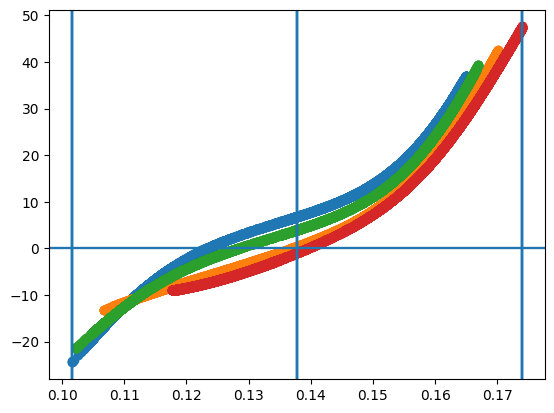

In [95]:
from matplotlib import pyplot as plt
model = nls_model
print(MASTER_DF['psi'].unique())
for psi in MASTER_DF['psi'].unique():
    # frame = (MASTER_DF['hop_idx'] == 20) & (MASTER_DF['psi'] == psi)
    frame = (MASTER_DF['psi'] == psi)
    df = MASTER_DF.loc[frame,:]
    l = df['l_m'].to_numpy()
    ldot = df['ldot'].to_numpy()
    lddot = df['lddot'].to_numpy()
    t = df['t_s'].to_numpy()
    Fs = model.spring_force(l,psi)
    Fd = model.dissipation_force(l,ldot,psi)
    plt.scatter(l, model.spring_force(l,psi))
    plt.axhline()
    for i in range(model.y.shape[0]):
        plt.axvline(model.y[i,0])
    # plt.scatter(ldot, ((Fd)))

In [96]:
# fit chi-squared distributions to models, packall information into dataframe for plotting
import pandas as pd
data_frame = pd.DataFrame(columns=['SOS','RSQR','RSQR_ADJ','RMSE','N', 'M', 'BIC','a','kind'])
rows = []
for result in classical_damping:
    errors = result.errors
    rows.append({
        'SOS' : result.fun,
        'RSQR' : result.r_sqr,
        'RSQR_ADJ' : result.r_sqr_adj,
        'RMSE' : result.rmse,
        'N' : result.num_params,
        'BIC' : result.bic,
        'AIK' : 2*result.num_params + result.sample_size*np.log(result.fun),
        'kind' : 'classical damping'
    })
for result in classical_spring:
    errors = result.errors
    rows.append({
        'SOS' : result.fun,
        'RSQR' : result.r_sqr,
        'RSQR_ADJ' : result.r_sqr_adj,
        'RMSE' : result.rmse,
        'N' : result.num_params,
        'BIC' : result.bic,
        'AIK' : 2*result.num_params + result.sample_size*np.log(result.fun),
        'kind' : 'classical spring'
    })
for result in generalized:
    errors = result.errors
    rows.append({
        'SOS' : result.fun,
        'RSQR' : result.r_sqr,
        'RSQR_ADJ' : result.r_sqr_adj,
        'RMSE' : result.rmse,
        'N' : result.num_params,
        'BIC' : result.bic,
        'AIK' : 2*result.num_params + result.sample_size*np.log(result.fun),
        'kind' : 'generalized'
    })

total_df= pd.DataFrame(rows)


NameError: name 'classical_damping' is not defined

In [ ]:
# configure matplotlib rcparams for style
import matplotlib.pyplot as plt
from cycler import cycler

# Set the font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

# Define a custom color cycle of 10 colors
colorblind_friendly_colors = ['#6a0dad', '#2ca02c', '#e2a000', '#1f77b4', '#ff7f0e', '#d62728']

# Update the default color cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=colorblind_friendly_colors)

In [ ]:
"""
Compare hopping trajectories to the prediction from forward simulation
"""
from hsa_hopper import dynamics

# integration step
def step(x,xdot,u,params,dt):
    a = dynamics.evaluate(x,xdot,u,params)
    return x+dt*xdot+.5*a*dt**2, xdot + dt*a 

# forward simulation loop
def forward_sim(x0,xdot0,ufunc,params,t0,tf,N_timesteps):
    x = np.zeros(N_timesteps)
    x[0] = x0
    xdot = np.zeros(N_timesteps)
    xdot[0] = xdot0
    t = np.linspace(t0,tf,N_timesteps)
    for i in range(N_timesteps-1):
        _x, _xdot = step(x[i],xdot[i],ufunc(t[i]),params,t[i+1]-t[i])
        x[i+1] = _x
        xdot[i+1] = _xdot
    return x,xdot,t

# select HSA model for params
generalized_result = generalized[-3]
classical_damping_result = classical_damping[-3]
classical_spring_result = classical_spring[-3]
generalized_params = dynamics.DynamicsParameters(
    hop_mass,
    generalized_result.J_x,
    generalized_result.b_x,
    0, # by
    0, # kx
    0, # x0
    kin_params,
    hsa_potential=generalized_result.model,
    psi=hopping_psi*np.pi/180
)
classical_spring_params = dynamics.DynamicsParameters(
    hop_mass,
    classical_spring_result.J_x,
    classical_spring_result.b_x,
    0, # by
    0, # kx
    0, # x0
    kin_params,
    hsa_potential=classical_spring_result.model,
    psi=hopping_psi*np.pi/180
)
classical_damping_params = dynamics.DynamicsParameters(
    hop_mass,
    classical_damping_result.J_x,
    classical_damping_result.b_x,
    0, # by
    0, # kx
    0, # x0
    kin_params,
    hsa_potential=classical_damping_result.model,
    psi=hopping_psi*np.pi/180
)
# construct interpolation function
from hsa_hopper import collocation
u_coeffs = np.array(hopping['experiment_config']['controller']['u_interp'][2]['mat'])[0]
u_tk = np.array(hopping['experiment_config']['controller']['u_interp'][2]['tk'])
covec = lambda t: collocation.interp_covector(t,u_tk[0],u_tk[1],len(u_coeffs))[0]

N_timesteps = 100
t_generalized_sim = []
x_generalized_sim = []
y_generalized_sim = []
t_classical_spring_sim = []
x_classical_spring_sim = []
y_classical_spring_sim = []
t_classical_damping_sim = []
x_classical_damping_sim = []
y_classical_damping_sim = []
t_emp = []
x_emp = []
y_emp = []

for idx,df in enumerate(hopping['data']):
    row = df.iloc[0,:]
    ufunc = lambda t: np.dot(covec(t),u_coeffs)
    t_emp.append(df['t'].to_numpy())
    t_emp[-1] = t_emp[-1]-t_emp[-1][0]
    x_emp.append(df['x'].to_numpy())
    xdot_emp = df['xdot'].to_numpy()
    t0 = t_emp[-1][0]
    tf = t_emp[-1][-1]
    x0 = x_emp[-1][0]
    xdot0 = xdot_emp[0]
    x_sim, xdot_sim, t_sim = forward_sim(x0,xdot0,ufunc,generalized_params,t0,tf,N_timesteps)
    y_sim = forward_kinematics(generalized_params.kinematics, x_sim)[0]
    t_generalized_sim.append(t_sim)
    x_generalized_sim.append(x_sim)
    y_generalized_sim.append(y_sim)
    x_sim, xdot_sim, t_sim = forward_sim(x0,xdot0,ufunc,classical_spring_params,t0,tf,N_timesteps)
    y_sim = forward_kinematics(classical_spring_params.kinematics, x_sim)[0]
    t_classical_spring_sim.append(t_sim)
    x_classical_spring_sim.append(x_sim)
    y_classical_spring_sim.append(y_sim)
    y_emp.append(forward_kinematics(classical_spring_params.kinematics, x_emp[-1])[0])
    x_sim, xdot_sim, t_sim = forward_sim(x0,xdot0,ufunc,classical_damping_params,t0,tf,N_timesteps)
    y_sim = forward_kinematics(classical_damping_params.kinematics, x_sim)[0]
    t_classical_damping_sim.append(t_sim)
    x_classical_damping_sim.append(x_sim)
    y_classical_damping_sim.append(y_sim)

Text(0.5, 1.0, 'Body Displacement Prediction Error During Hopping')

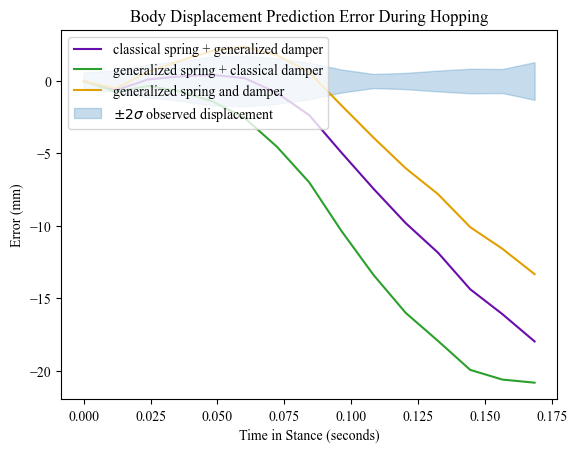

In [ ]:
tf_min = np.min([t[-1] for t in t_emp])
t_linspace = np.linspace(0,tf_min,15)
y_generalized_interp = np.array([np.interp(t_linspace, t_generalized_sim[i], y_generalized_sim[i]) for i in range(len(y_generalized_sim))])
y_classical_spring_interp = np.array([np.interp(t_linspace, t_classical_spring_sim[i], y_classical_spring_sim[i]) for i in range(len(y_classical_spring_sim))])
y_classical_damping_interp = np.array([np.interp(t_linspace, t_classical_damping_sim[i], y_classical_damping_sim[i]) for i in range(len(y_classical_damping_sim))])
y_emp_interp = np.array([np.interp(t_linspace, t_emp[i], y_emp[i]) for i in range(len(x_emp))])

y_generalized_mean = np.mean(y_generalized_interp-y_emp_interp, axis=0)
y_classical_spring_mean = np.mean(y_classical_spring_interp-y_emp_interp, axis=0)
y_classical_damping_mean = np.mean(y_classical_damping_interp-y_emp_interp, axis=0)
y_emp_mean = np.mean(y_emp_interp, axis=0)
y_emp_std = np.std(y_emp_interp, axis=0)

plt.plot(t_linspace, 1000*(y_classical_spring_mean), color='C0', label='classical spring + generalized damper')
plt.plot(t_linspace, 1000*(y_classical_damping_mean), color='C1', label='generalized spring + classical damper')
plt.plot(t_linspace, 1000*(y_generalized_mean), color='C2', label='generalized spring and damper')
plt.fill_between(t_linspace, 1000*(-2*y_emp_std), 1000*(2*y_emp_std), color='C3', alpha=.25, label=r'$\pm 2\sigma$ observed displacement')
plt.legend(loc='upper left')
plt.xlabel('Time in Stance (seconds)')
plt.ylabel('Error (mm)')
plt.title('Body Displacement Prediction Error During Hopping')


In [ ]:
horizon = 6
model_params = {
    'NL-S L-D' : classical_damping_params,
    'L-S NL-D' : classical_spring_params,
    'NL-SD' : generalized_params

}
finite_horizon_sim_data = {
    'Model' : [],
    'Horizon' : [],
    'RMSE' : [],
}

for model, params in model_params.items():

    for idx,df in enumerate(hopping['data']):
        row = df.iloc[0,:]
        ufunc = lambda t: np.dot(covec(t),u_coeffs)
        t = df['t'].to_numpy()
        t = t - t[0]     # zero time for correct interpolation of feed-forward input
        x = df['x'].to_numpy()
        y = forward_kinematics(params.kinematics, x)[0]
        xdot = df['xdot'].to_numpy()

        errors = np.zeros((t.size-horizon, horizon-1))
        for i in range(t.size-horizon):
            ufunc = lambda t: np.dot(covec(t),u_coeffs)
            t0 = t[i]
            x0 = x[i]
            xdot0 = xdot[i]
            x_sim, xdot_sim, t_sim = forward_sim(x0, xdot0, ufunc, params, t0, t[i+horizon], horizon)
            y_sim = forward_kinematics(params.kinematics, x_sim)[0]
            errors[i,:] = y_sim[1:] - y[i+1:i+horizon]
    finite_horizon_sim_data['Model'].append(model)
    finite_horizon_sim_data['Horizon'].append(horizon)
    finite_horizon_sim_data['RMSE'].append(np.sqrt(np.average(errors**2, axis=0)))
    # x_sim, xdot_sim, t_sim = forward_sim(x0,xdot0,ufunc,generalized_params,t0,tf,N_timesteps)
    # y_sim = forward_kinematics(generalized_params.kinematics, x_sim)[0]
    # t_generalized_sim.append(t_sim)
    # x_generalized_sim.append(x_sim)
    # y_generalized_sim.append(y_sim)
    # x_sim, xdot_sim, t_sim = forward_sim(x0,xdot0,ufunc,classical_spring_params,t0,tf,N_timesteps)
    # y_sim = forward_kinematics(classical_spring_params.kinematics, x_sim)[0]
    # t_classical_spring_sim.append(t_sim)
    # x_classical_spring_sim.append(x_sim)
    # y_classical_spring_sim.append(y_sim)
    # y_emp.append(forward_kinematics(classical_spring_params.kinematics, x_emp[-1])[0])
    # x_sim, xdot_sim, t_sim = forward_sim(x0,xdot0,ufunc,classical_damping_params,t0,tf,N_timesteps)
    # y_sim = forward_kinematics(classical_damping_params.kinematics, x_sim)[0]
    # t_classical_damping_sim.append(t_sim)
    # x_classical_damping_sim.append(x_sim)
    # y_classical_damping_sim.append(y_sim)

In [ ]:
finite_horizon_sim_data

{'Model': ['NL-S L-D', 'L-S NL-D', 'NL-SD'],
 'Horizon': [6, 6, 6],
 'RMSE': [array([0.00167822, 0.00454328, 0.00953917, 0.01323557, 0.01081517]),
  array([0.00076855, 0.00243727, 0.00533886, 0.00757897, 0.00636984]),
  array([0.00069003, 0.00321911, 0.00461862, 0.00443465, 0.00260199])]}

Text(0.5, 1.0, '(b) Adjusted $R^2$ (percent)')

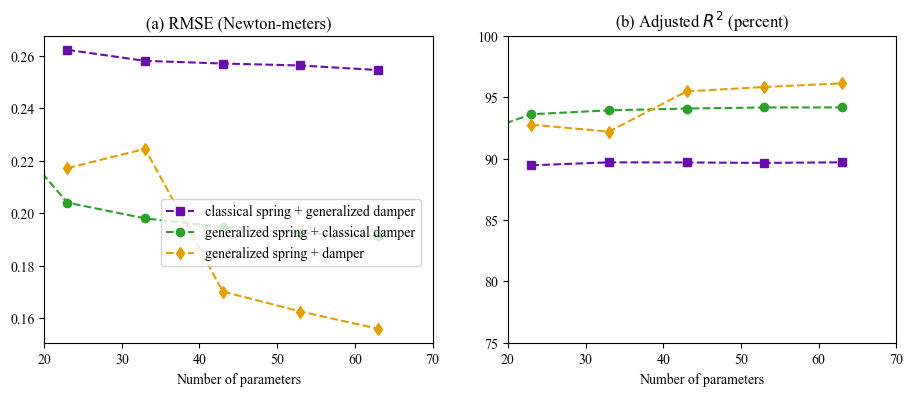

In [ ]:
# RMSE / Adjusted R^2 plot combined
fig, axs = plt.subplots(1,2,sharex=True)
fig.tight_layout()
fig.set_figheight(3.5)
fig.set_figwidth(9.5)
sub_df = total_df[total_df['kind'] == 'classical spring']
N1 = sub_df['N'].to_numpy()
y1 = sub_df['RMSE'].to_numpy()
axs[0].plot(N1, y1, label='classical spring + generalized damper',marker='s', linestyle='dashed')
sub_df = total_df[total_df['kind'] == 'classical damping']
N2 = sub_df['N'].to_numpy()
y2 = sub_df['RMSE'].to_numpy()
axs[0].plot(N2, y2, label='generalized spring + classical damper',marker='o', linestyle='dashed')
sub_df = total_df[total_df['kind'] == 'generalized']
N3 = sub_df['N'].to_numpy()
y3 = sub_df['RMSE'].to_numpy()
axs[0].plot(N3, y3, label='generalized spring + damper',marker='d', linestyle='dashed')

# for i, N in enumerate(N1):
#     if M1[i] in [4,5,6,7]:
#         # if i < 3:
#         axs[0].annotate(f'{M1[i]}', (N1[i],y1[i]), xytext=(-5,10), xycoords='data', textcoords='offset pixels')
#         # else:
#             # axs[0].annotate(f'M = {M1[i]}', (N1[i],y1[i]), xytext=(-5,-20), xycoords='data', textcoords='offset pixels')
# for i, N in enumerate(N2):
#     axs[0].annotate(f'{M2[i]}', (N2[i],y2[i]), xytext=(-5,5), xycoords='data', textcoords='offset pixels')


axs[0].set_xlim(15,120)
axs[0].set_xlabel('Number of parameters')
axs[0].set_title('(a) RMSE (Newton-meters)')
axs[0].legend(loc=(.3,.25))

sub_df = total_df[total_df['kind'] == 'classical spring']
N1 = sub_df['N'].to_numpy()
y1 = sub_df['RSQR_ADJ'].to_numpy()
axs[1].plot(N1, 100*y1, label='classical spring + generalized damper',marker='s', linestyle='dashed')
sub_df = total_df[total_df['kind'] == 'classical damping']
N2 = sub_df['N'].to_numpy()
y2 = sub_df['RSQR_ADJ'].to_numpy()
axs[1].plot(N2, 100*y2, label='generalized spring + classical damper',marker='o', linestyle='dashed')
sub_df = total_df[total_df['kind'] == 'generalized']
N3 = sub_df['N'].to_numpy()
y3 = sub_df['RSQR_ADJ'].to_numpy()
axs[1].plot(N3, 100*y3, label='generalized spring + damper',marker='d', linestyle='dashed')

axs[1].set_xlim(20,70)
axs[1].set_ylim(75,100)
# axs[1].legend()
axs[1].set_xlabel('Number of parameters')
axs[1].set_title(r'(b) Adjusted $R^2$ (percent)')

(11.0, 18.5)

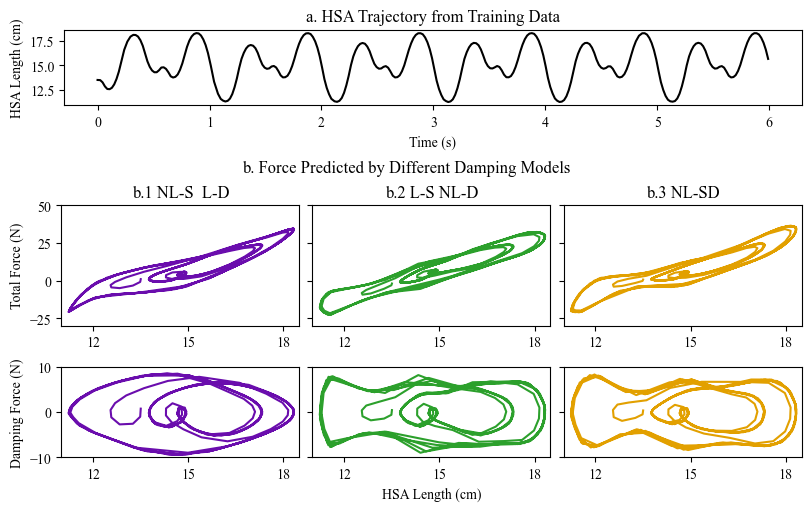

In [ ]:
# plot to compare Force/Length for different values of psi under the chosen model (nonlinear, M=6)
from matplotlib.gridspec import GridSpec
from scipy.stats import norm
supfig = plt.figure(layout='constrained', figsize=(8,5))
figs = supfig.subfigures(nrows=3,ncols=1,height_ratios=([.3,.4,.3]))

# get data from HSA characterization
idx = 1
df = characterization['data'][idx]
psi_idx = i = 0
psi = df['psi'].to_numpy()[0]
l = df['l'].to_numpy()
ldot = df['ldot'].to_numpy()
t = df['t'].to_numpy()
l_min = np.min(l[i])
l_max = np.max(l[i])
l_linspace = np.arange(l_min, l_max, .005)
model1 = classical_damping[3].model
model2 = classical_spring[3].model
model3 = generalized[3].model

# plot trajectory of training data
axstop = figs[0].subplots()
axstop.plot(t-t[0],100*l,color='black')
# axstop.plot(t[i][1:-1]-t[i][0],100*ldot,color='black')
axstop.set_xlabel('Time (s)')
axstop.set_ylabel('HSA Length (cm)')
axstop.set_title('a. HSA Trajectory from Training Data')

# calculate elastic force and plot in 1x3 subfig with sharex and sharey
axsmid = figs[1].subplots(1,3,sharex=True,sharey=True)
elastic_force1 = np.array([model1.dV([l[i],psi]) for i in range(len(l))])
damp_force1 = np.array([model1.dR([l[i],psi],[ldot[i],0]) for i in range(len(l))])
elastic_force_dashed1 = np.array([model1.dV([_l,psi]) for _l in l_linspace])
axsmid[0].plot(100*l,elastic_force1+damp_force1,color='C0')
axsmid[0].plot(100*l_linspace,elastic_force_dashed1,color='black', linestyle='dashed')
axsmid[0].set_title('b.1 NL-S  L-D')
figs[1].suptitle('b. Force Predicted by Different Damping Models')

elastic_force2 = np.array([model2.dV([l[i],psi]) for i in range(len(l))])
damp_force2 = np.array([model2.dR([l[i],psi],[ldot[i],0]) for i in range(len(l))])
elastic_force_dashed2 = np.array([model2.dV([_l,psi]) for _l in l_linspace])
axsmid[1].plot(100*l,elastic_force2+damp_force2,color='C1')
axsmid[1].plot(100*l_linspace,elastic_force_dashed2,color='black', linestyle='dashed')
axsmid[1].set_title('b.2 L-S NL-D')

elastic_force3 = np.array([model3.dV([l[i],psi]) for i in range(len(l))])
damp_force3 = np.array([model3.dR([l[i],psi],[ldot[i],0]) for i in range(len(l))])
elastic_force_dashed3 = np.array([model3.dV([_l,psi]) for _l in l_linspace])
axsmid[2].plot(100*l,elastic_force3+damp_force3,color='C2')
axsmid[2].plot(100*l_linspace,elastic_force_dashed3,color='black', linestyle='dashed')
axsmid[2].set_title('b.3 NL-SD')
axsmid[0].set_ylim(-30,50)
axsmid[0].set_yticks([-25,0,25,50])
axsmid[0].set_ylabel('Total Force (N)')
axsmid[0].set_xticks([12,15,18])
axsmid[0].set_xlim((11,18.5))

# now damping force plots
axsbot = figs[2].subplots(1,3,sharex=True,sharey=True)
axsbot[0].plot(100*l,damp_force1,color='C0')
axsbot[1].plot(100*l,damp_force2,color='C1')
axsbot[2].plot(100*l,damp_force3,color='C2')
axsbot[1].set_xlabel('HSA Length (cm)')
axsbot[0].set_ylabel('Damping Force (N)')
axsbot[0].set_ylim(-10,10)
axsbot[0].set_xticks([12,15,18])
axsbot[0].set_xlim((11,18.5))

# axsfinal = figs[3].subplots(1,3,sharex=True,sharey=True)
# errors1 = classical_models[3].errors
# errors2 = generalized_models[3].errors
# errors3 = nonlinear_models[3].errors
# all_errors = np.hstack((errors1,errors2,errors3))
# sigma = np.std(all_errors)
# rv_params1 = norm.fit(errors1)
# axsfinal[0].hist(errors1, range=(-3*sigma,3*sigma), bins=20, density=True)
# axsfinal[1].hist(errors2, range=(-3*sigma,3*sigma), bins=20, density=True)
# axsfinal[2].hist(errors3, range=(-3*sigma,3*sigma), bins=20, density=True)


ValueError: x and y must have same first dimension, but have shapes (1,) and (286,)

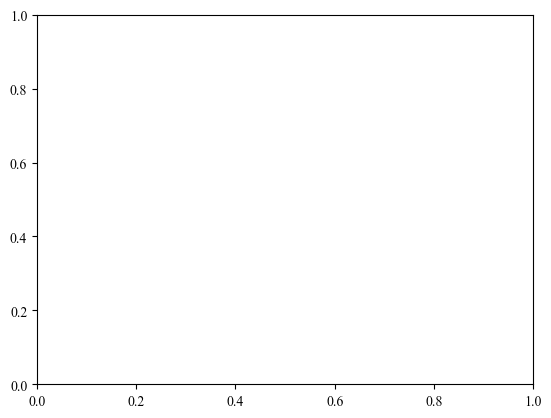

In [ ]:
plt.plot(ldot[i],damp_force3*ldot[i])